In [7]:
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv('../data/processed/multiple_cause_of_death_1999_2020_T400_T406.csv')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23011 entries, 0 to 23010
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   State                         23011 non-null  object
 1   State Code                    23011 non-null  int64 
 2   Year                          23011 non-null  int64 
 3   Year Code                     23011 non-null  int64 
 4   Five-Year Age Groups          23011 non-null  object
 5   Five-Year Age Groups Code     23011 non-null  object
 6   Sex                           23011 non-null  object
 7   Sex Code                      23011 non-null  object
 8   Multiple Cause of death       23011 non-null  object
 9   Multiple Cause of death Code  23011 non-null  object
 10  Deaths                        23011 non-null  int64 
 11  Population                    23011 non-null  int64 
 12  Crude Rate                    23011 non-null  object
dtypes: int64(5), obj

In [38]:
df.head()

,State,State Code,Year,Year Code,Five-Year Age Groups,Five-Year Age Groups Code,Sex,Sex Code,Multiple Cause of death,Multiple Cause of death Code,Deaths,Population,Crude Rate
0,Alabama,1,2014,2014,30-34 years,30-34,Male,M,Heroin,T40.1,15,151961,Unreliable
1,Alabama,1,2014,2014,35-39 years,35-39,Female,F,Heroin,T40.1,10,150784,Unreliable
2,Alabama,1,2014,2014,35-39 years,35-39,Male,M,Heroin,T40.1,12,142893,Unreliable
3,Alabama,1,2014,2014,40-44 years,40-44,Male,M,Heroin,T40.1,11,152072,Unreliable
4,Alabama,1,2015,2015,25-29 years,25-29,Male,M,Heroin,T40.1,13,160487,Unreliable


In [39]:
df.tail()

,State,State Code,Year,Year Code,Five-Year Age Groups,Five-Year Age Groups Code,Sex,Sex Code,Multiple Cause of death,Multiple Cause of death Code,Deaths,Population,Crude Rate
23006,Wisconsin,55,2020,2020,55-59 years,55-59,Female,F,Other synthetic narcotics,T40.4,25,209450,11.94
23007,Wisconsin,55,2020,2020,55-59 years,55-59,Male,M,Other synthetic narcotics,T40.4,52,204597,25.42
23008,Wisconsin,55,2020,2020,60-64 years,60-64,Female,F,Other synthetic narcotics,T40.4,13,205874,Unreliable
23009,Wisconsin,55,2020,2020,60-64 years,60-64,Male,M,Other synthetic narcotics,T40.4,42,199932,21.01
23010,Wisconsin,55,2020,2020,65-69 years,65-69,Male,M,Other synthetic narcotics,T40.4,14,170341,Unreliable


In [41]:
df.isna().sum()

State                           0
State Code                      0
Year                            0
Year Code                       0
Five-Year Age Groups            0
Five-Year Age Groups Code       0
Sex                             0
Sex Code                        0
Multiple Cause of death         0
Multiple Cause of death Code    0
Deaths                          0
Population                      0
Crude Rate                      0
dtype: int64

In [24]:
df.nunique()

State                             45
State Code                        45
Year                              22
Year Code                         22
Five-Year Age Groups              14
Five-Year Age Groups Code         14
Sex                                2
Sex Code                           2
Multiple Cause of death            6
Multiple Cause of death Code       6
Deaths                           282
Population                      9071
Crude Rate                      3394
dtype: int64

In [28]:
df['State'].unique()

array(['Alabama', 'Alaska', 'Arizona', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'District of Columbia', 'Florida',
       'Georgia', 'Illinois', 'Indiana', 'Iowa', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Nevada', 'New Hampshire', 'New Jersey',
       'New Mexico', 'New York', 'North Carolina', 'Ohio', 'Oklahoma',
       'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina',
       'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Arkansas', 'Kansas', 'Montana'],
      dtype=object)

In [43]:
expected_states = [
    'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
    'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia',
    'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
    'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
    'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
    'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota',
    'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina',
    'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia',
    'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'
]

actual_states = df['State'].unique()
print(actual_states)

['Alabama' 'Alaska' 'Arizona' 'California' 'Colorado' 'Connecticut'
 'Delaware' 'District of Columbia' 'Florida' 'Georgia' 'Illinois'
 'Indiana' 'Iowa' 'Kentucky' 'Louisiana' 'Maine' 'Maryland'
 'Massachusetts' 'Michigan' 'Minnesota' 'Mississippi' 'Missouri' 'Nevada'
 'New Hampshire' 'New Jersey' 'New Mexico' 'New York' 'North Carolina'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'Tennessee' 'Texas' 'Utah' 'Vermont' 'Virginia' 'Washington'
 'West Virginia' 'Wisconsin' 'Arkansas' 'Kansas' 'Montana']


In [45]:
missing_states = [state for state in expected_states if state not in actual_states]
missing_states

['Hawaii', 'Idaho', 'Nebraska', 'North Dakota', 'South Dakota', 'Wyoming']

The Multiple Cause of Death data available on WONDER are county-level national mortality and population data spanning the years 1999-2020. Data are based on death certificates for U.S. residents. Each death certificate contains a single underlying cause of death, up to twenty additional multiple causes, and demographic data. The number of deaths, crude death rates, age-adjusted death rates and 95% confidence intervals for death rates can be obtained by cause of death (4 digit ICD-10 codes, 113 selected causes of death, 130 selected causes of infant death, drug and alcohol related causes of death, injury intent and injury mechanism categories), place of residence (national, region, division, state, and county), age (single-year-of age, 5-year age groups, 10-year age groups and infant age groups), race (American Indian or Alaskan Native, Asian/Pacific Islander, Black or African American, White), Hispanic ethnicity, sex and year. Data are also available by place of death, month and week day of death, and whether an autopsy was performed.

Privacy policy: Statistics representing fewer than ten (one to nine) deaths or births are suppressed. Population figures are also suppressed when the population represents fewer than ten persons. Additional privacy constraints apply to infant mortality statistics for infant age groups and live births denominator population figures. See Assurance of Confidentiality for more information. 

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23011 entries, 0 to 23010
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   State                         23011 non-null  object
 1   State Code                    23011 non-null  int64 
 2   Year                          23011 non-null  int64 
 3   Year Code                     23011 non-null  int64 
 4   Five-Year Age Groups          23011 non-null  object
 5   Five-Year Age Groups Code     23011 non-null  object
 6   Sex                           23011 non-null  object
 7   Sex Code                      23011 non-null  object
 8   Multiple Cause of death       23011 non-null  object
 9   Multiple Cause of death Code  23011 non-null  object
 10  Deaths                        23011 non-null  int64 
 11  Population                    23011 non-null  int64 
 12  Crude Rate                    23011 non-null  object
dtypes: int64(5), obj

In [56]:
df['Year'].min() 

1999

In [57]:
df['Year'].max()

2020

In [58]:
df['Year'].isna().sum()

0

In [65]:
sorted(df['Year'].unique())

[1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020]

In [66]:
df['Five-Year Age Groups'].isna().sum()

0

In [67]:
df['Five-Year Age Groups'].nunique()

14

In [69]:
sorted(df['Five-Year Age Groups'].unique())

['15-19 years',
 '20-24 years',
 '25-29 years',
 '30-34 years',
 '35-39 years',
 '40-44 years',
 '45-49 years',
 '50-54 years',
 '55-59 years',
 '60-64 years ',
 '65-69 years',
 '70-74 years',
 '75-79 years',
 '80-84 years']

In [73]:
df['Five-Year Age Groups'] = df['Five-Year Age Groups'].str.strip()
sorted(df['Five-Year Age Groups'].unique())

['15-19 years',
 '20-24 years',
 '25-29 years',
 '30-34 years',
 '35-39 years',
 '40-44 years',
 '45-49 years',
 '50-54 years',
 '55-59 years',
 '60-64 years',
 '65-69 years',
 '70-74 years',
 '75-79 years',
 '80-84 years']

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23011 entries, 0 to 23010
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   State                         23011 non-null  object
 1   State Code                    23011 non-null  int64 
 2   Year                          23011 non-null  int64 
 3   Year Code                     23011 non-null  int64 
 4   Five-Year Age Groups          23011 non-null  object
 5   Five-Year Age Groups Code     23011 non-null  object
 6   Sex                           23011 non-null  object
 7   Sex Code                      23011 non-null  object
 8   Multiple Cause of death       23011 non-null  object
 9   Multiple Cause of death Code  23011 non-null  object
 10  Deaths                        23011 non-null  int64 
 11  Population                    23011 non-null  int64 
 12  Crude Rate                    23011 non-null  object
dtypes: int64(5), obj

In [75]:
df['Sex'].unique()

array(['Male', 'Female'], dtype=object)

In [76]:
df['Multiple Cause of death'].nunique()

6

In [77]:
df['Multiple Cause of death'].unique()

array(['Heroin', 'Other opioids', 'Cocaine',
       'Other and unspecified narcotics', 'Methadone',
       'Other synthetic narcotics'], dtype=object)

In [84]:
df.groupby('State')['Deaths'].sum().sort_values(ascending = False).head(10)

State
Florida           57817
California        57478
New York          57361
Ohio              49706
Illinois          38297
Pennsylvania      34397
Texas             33710
Massachusetts     29507
North Carolina    27326
Maryland          27187
Name: Deaths, dtype: int64

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23011 entries, 0 to 23010
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   State                         23011 non-null  object
 1   State Code                    23011 non-null  int64 
 2   Year                          23011 non-null  int64 
 3   Year Code                     23011 non-null  int64 
 4   Five-Year Age Groups          23011 non-null  object
 5   Five-Year Age Groups Code     23011 non-null  object
 6   Sex                           23011 non-null  object
 7   Sex Code                      23011 non-null  object
 8   Multiple Cause of death       23011 non-null  object
 9   Multiple Cause of death Code  23011 non-null  object
 10  Deaths                        23011 non-null  int64 
 11  Population                    23011 non-null  int64 
 12  Crude Rate                    23011 non-null  object
dtypes: int64(5), obj

In [93]:
sorted(df['Five-Year Age Groups'].unique())

['15-19 years',
 '20-24 years',
 '25-29 years',
 '30-34 years',
 '35-39 years',
 '40-44 years',
 '45-49 years',
 '50-54 years',
 '55-59 years',
 '60-64 years',
 '65-69 years',
 '70-74 years',
 '75-79 years',
 '80-84 years']

In [ ]:
wave_df = df.groupby(['Year', 'Multiple Cause of death Code'])['Deaths'].sum().reset_index()

In [86]:
df_wave = df.groupby(['Year', 'Multiple Cause of death Code'])['Deaths'].sum().reset_index()
df_wave

,Year,Multiple Cause of death Code,Deaths
0,1999,T40.1,1251
1,1999,T40.2,1501
2,1999,T40.3,154
3,1999,T40.4,36
4,1999,T40.5,2997
...,...,...,...
127,2020,T40.2,11394
128,2020,T40.3,1481
129,2020,T40.4,55547
130,2020,T40.5,18653


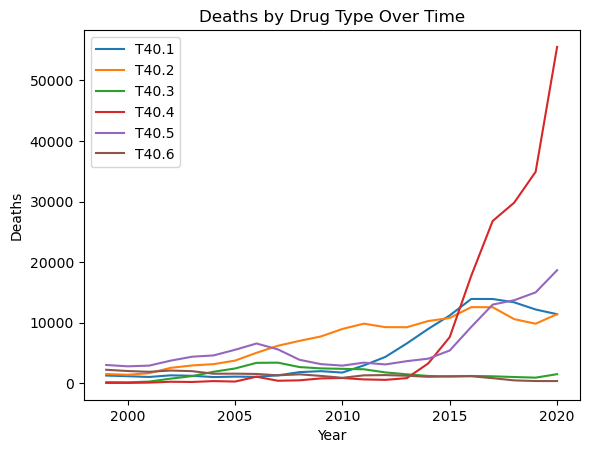

In [87]:
import matplotlib.pyplot as plt

for code in df_wave['Multiple Cause of death Code'].unique():
    subset = df_wave[df_wave['Multiple Cause of death Code'] == code]
    plt.plot(subset['Year'], subset['Deaths'], label=code)

plt.legend()
plt.title('Deaths by Drug Type Over Time')
plt.xlabel('Year')
plt.ylabel('Deaths')
plt.show()